In [ ]:
import numpy as np
import pandas as pd

url = 'https://gist.githubusercontent.com/MuhammetOzturk/caf476e7b51c2be4aca2e60d53007b2a/raw/15ed8c1dd2215bba1b2ff3fc0655b9ea206d75b6/Titanic.csv'
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df_orginal = df.copy()
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch','Fare', 'Embarked','Survived']]
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


# Sinifa Gore Hayatta Kalma Durumlari

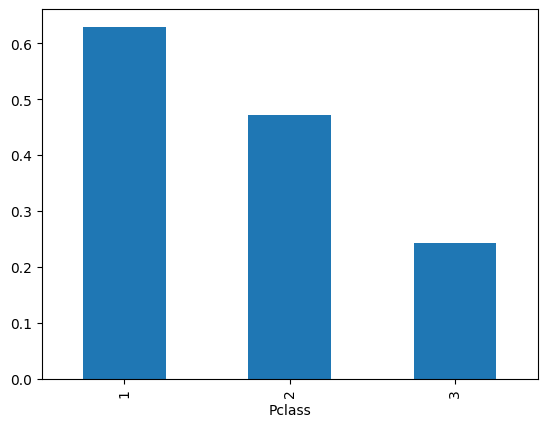

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.show()

```python
x = pd.DataFrame(df.groupby('Pclass'))
x
```

```python
x[1].loc[0]
```

# Cinsiyete Gore Hayatta Kalma Durumlari

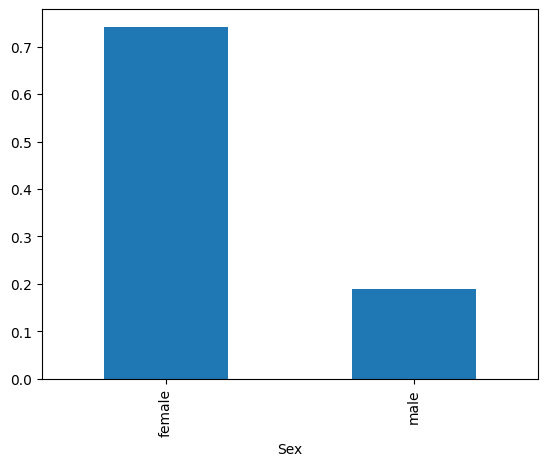

In [ ]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.show()

# Yasa Gore Gruplandirma

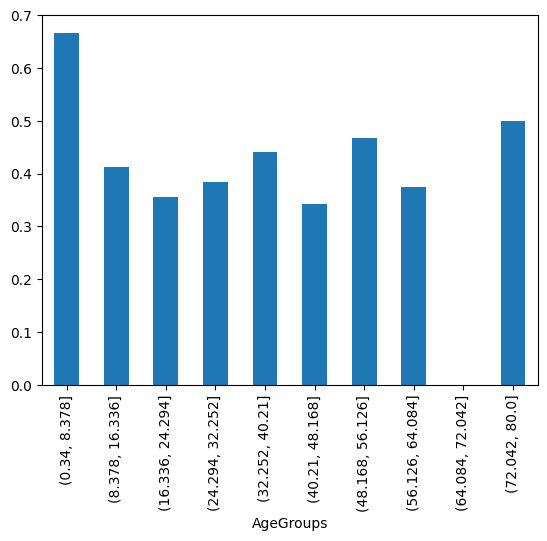

In [ ]:
df['AgeGroups'] = pd.cut(df['Age'], 10)
df.groupby('AgeGroups',observed=True)['Survived'].mean().plot(kind='bar')
plt.show()

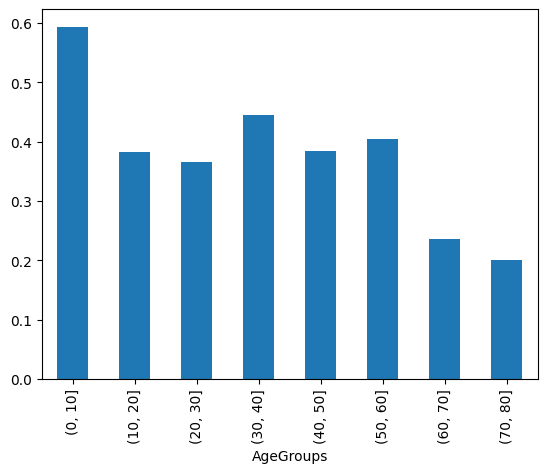

In [ ]:
df['AgeGroups'] = pd.cut(df['Age'], range(0,81,10))
df.groupby('AgeGroups',observed=True)['Survived'].mean().plot(kind='bar')
plt.show()

# Kardes/Es Sayisina Gore Hayatta Kalma Durumlari

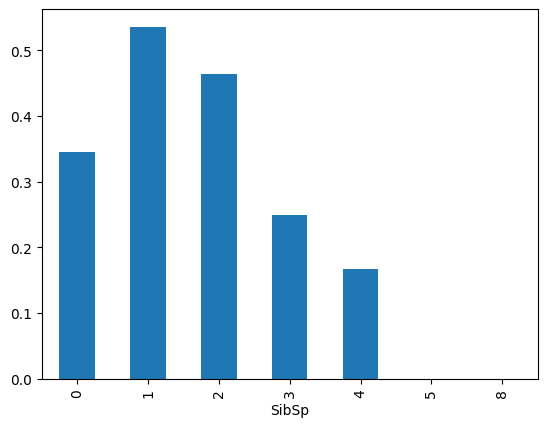

In [ ]:
df.groupby('SibSp')['Survived'].mean().plot(kind='bar')
plt.show()

# Ebevyen/Cocuk Sayisina Gore Hayatta Kalma Durumlari

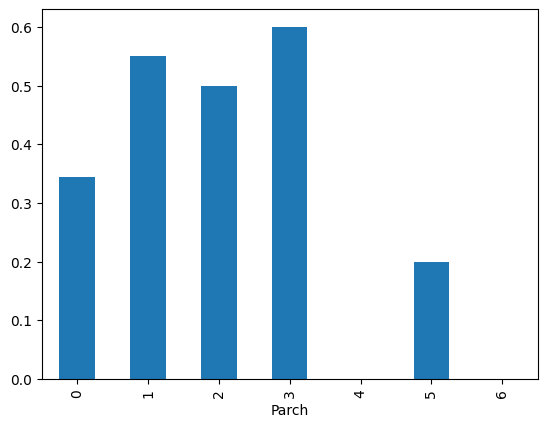

In [ ]:
df.groupby('Parch')['Survived'].mean().plot(kind='bar')
plt.show()

# Bilet Ucretine Gore Hayatta Kalma Durumlari

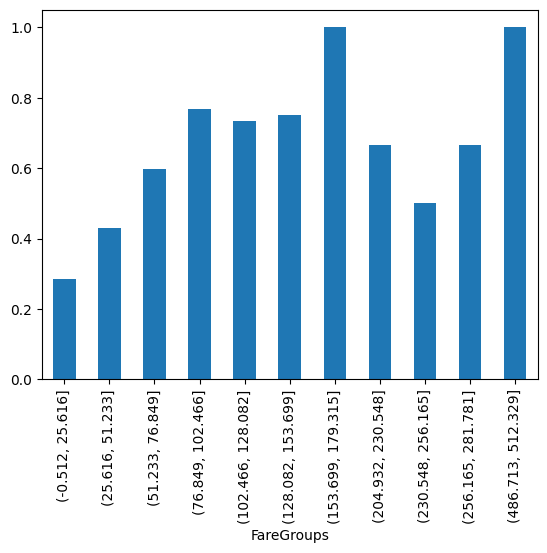

In [ ]:
df['FareGroups'] = pd.cut(df['Fare'], 20)
df.groupby('FareGroups',observed=True)['Survived'].mean().plot(kind='bar')
plt.show()

# Limanlara Gore Hayatta Kalma Durumlari

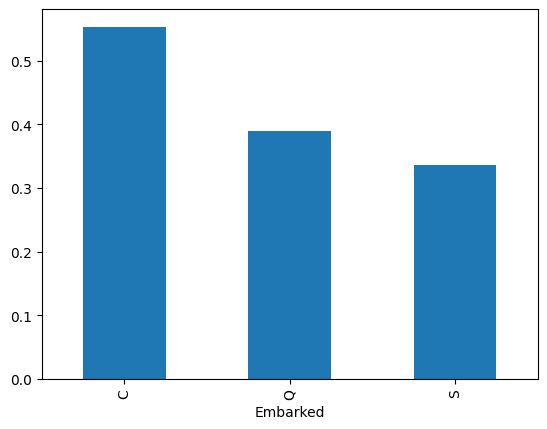

In [ ]:
df.groupby('Embarked')['Survived'].mean().plot(kind='bar')
plt.show()


# Limanlara Gore Sinif Dagilimi

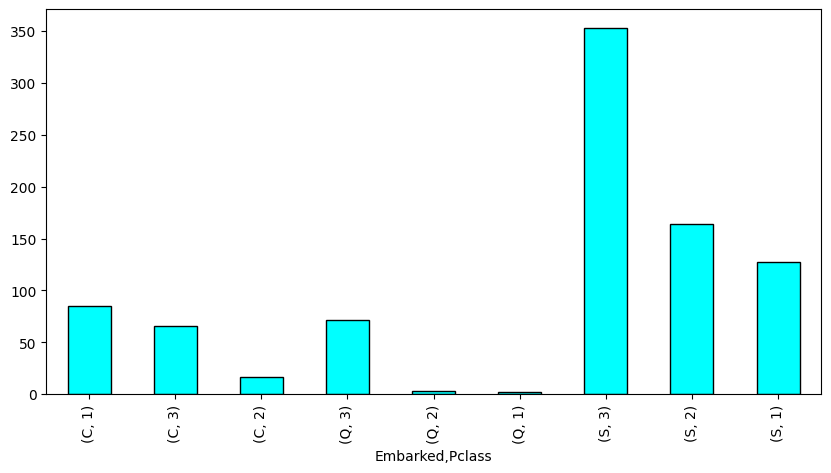

In [ ]:
df.groupby('Embarked')['Pclass'].value_counts().plot(kind='bar', color='#00FFFF',edgecolor='black', figsize=(10,5))
plt.show()

In [ ]:
df.isna().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2
Survived,0
AgeGroups,177
FareGroups,0


In [ ]:
age_mean = df['Age'].mean()
df.fillna({'Age':age_mean}, inplace=True)
df.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2
Survived,0
AgeGroups,177
FareGroups,0


In [ ]:
#Q ,C , S
en_cok_binilen_liman = df.Embarked.mode()[0]
df.fillna({'Embarked':en_cok_binilen_liman}, inplace=True)
df.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Survived,0
AgeGroups,177
FareGroups,0


In [ ]:
df.drop('AgeGroups', axis=1, inplace=True)
df.drop('FareGroups', axis=1, inplace=True)
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le

LabelEncoder()

In [ ]:
df['Sex'] = le.fit_transform(df['Sex'])
df.head(8).round(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,22.0,1,0,7.25,S,0
1,1,0,38.0,1,0,71.28,C,1
2,3,0,26.0,0,0,7.92,S,1
3,1,0,35.0,1,0,53.10,S,1
4,3,1,35.0,0,0,8.05,S,0
5,3,1,29.7,0,0,8.46,Q,0
6,1,1,54.0,0,0,51.86,S,0
7,3,1,2.0,3,1,21.08,S,0


In [ ]:
df['Embarked'] = le.fit_transform(df['Embarked'])
df.head(8).round(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,22.0,1,0,7.25,2,0
1,1,0,38.0,1,0,71.28,0,1
2,3,0,26.0,0,0,7.92,2,1
3,1,0,35.0,1,0,53.10,2,1
4,3,1,35.0,0,0,8.05,2,0
5,3,1,29.7,0,0,8.46,1,0
6,1,1,54.0,0,0,51.86,2,0
7,3,1,2.0,3,1,21.08,2,0


In [ ]:
X = df.iloc[:,:-1]
y = df['Survived']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=3, random_state=42)
model.fit(X, y)


RandomForestClassifier(n_estimators=3, random_state=42)

In [ ]:
model.predict(df.iloc[:5,:-1])

array([0, 1, 0, 1, 0])

In [ ]:
result = model.predict(df.iloc[:,:-1])
result

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,

# Basari Orani

In [ ]:
(result == df['Survived']).sum() / len(result)

np.float64(0.9506172839506173)

# Egitim Ve Test Veri Seti Olarak Ayirma

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [ ]:
X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,3,1,29.699118,1,1,15.2458,0
439,2,1,31.000000,0,0,10.5000,2
840,3,1,20.000000,0,0,7.9250,2
720,2,0,6.000000,0,1,33.0000,2
39,3,0,14.000000,1,0,11.2417,0


In [ ]:
y_test.head()

,Survived
709,1
439,0
840,0
720,1
39,1


In [ ]:
model = RandomForestClassifier(n_estimators=3, random_state=1)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=3, random_state=1)

In [ ]:
#Test Asamasi
result = model.predict(X_test)

In [ ]:
((result == y_test).sum() / len(result)).round(2).item()

0.82

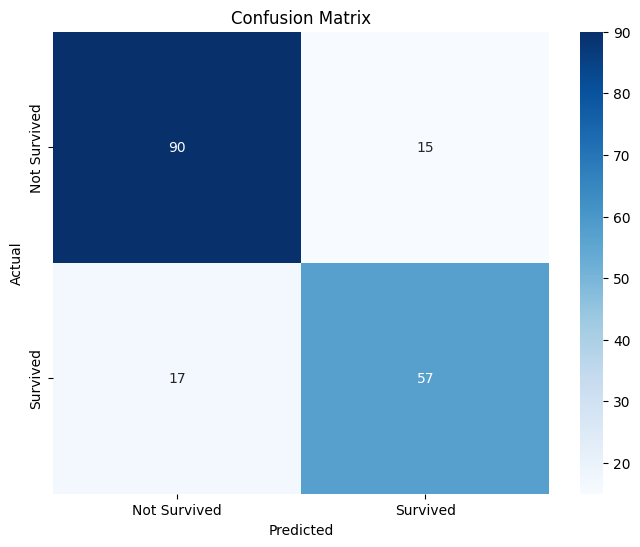

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, result)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()